# Figure 4B. Virome profiling benchmark

In [ ]:
### Extract HQ viruses from comprehensivity benchmark (figure 2E) for each body site ###
import polars as pl

# load samplesheets
gut_samplesheet = pl.read_csv('gut_samplesheet.csv').with_columns([pl.lit('gut').alias('body_site')])
oral_samplesheet = pl.read_csv('oral_samplesheet.csv').with_columns([pl.lit('oral').alias('body_site')])
skin_samplesheet = pl.read_csv('skin_samplesheet.csv').with_columns([pl.lit('skin').alias('body_site')])
urogenital_samplesheet = pl.read_csv('urogenital_samplesheet.csv').with_columns([pl.lit('urogenital').alias('body_site')])
combined_samplesheet = pl.concat([gut_samplesheet, oral_samplesheet, skin_samplesheet, urogenital_samplesheet])

# !grep "^>" combined_renamed.fna > combined_renamed.fna.ids

# assign sequences to body sites
seq2site = (
    pl.read_csv('virome_profiling/combined_renamed.fna.ids', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# write out body site specific sequence ids
for site in ['gut', 'oral', 'skin', 'urogenital']:
    seq2site.filter(pl.col('body_site') == site).select('qname').write_csv(f'{site}_hq_virus_ids.txt')

# create body site specific fasta files
!for site in gut oral skin urogenital; do \
    mkdir -p ${site}_hq_viruses; \
    seqkit grep \
        combined_renamed.fna \
        --pattern-file ${site}_hq_virus_ids.txt \
        -o ${site}_hq_viruses/${site}_hq_viruses.fna; \
done

In [ ]:
%%bash
### Cluster into vOTUs within each body site ###
for site in gut oral skin urogenital; do
    vclust \
        prefilter \
        --in virome_profiling/${site}_hq_viruses/${site}_hq_viruses.fna \
        --out virome_profiling/${site}_hq_viruses/${site}.vclust_prefilter.txt \
        --threads 48 \
        --min-ident 0.95

    vclust \
        align \
        --in virome_profiling/${site}_hq_viruses/${site}_hq_viruses.fna \
        --out virome_profiling/${site}_hq_viruses/${site}.vclust_ani.tsv \
        --filter virome_profiling/${site}_hq_viruses/${site}.vclust_prefilter.txt \
        --threads 48 \
        --out-ani 0.95 \
        --out-qcov 0.85

    vclust \
        cluster \
        --in virome_profiling/${site}_hq_viruses/${site}.vclust_ani.tsv\
        --ids virome_profiling/${site}_hq_viruses/${site}.vclust_ani.ids.tsv \
        --out virome_profiling/${site}_hq_viruses/${site}.vclust_clusters.tsv \
        --algorithm cd-hit \
        --metric ani \
        --ani 0.995 \
        --qcov 1.0 \
        --out-repr

    csvtk \
        cut \
        virome_profiling/${site}_hq_viruses/${site}.vclust_clusters.tsv \
        --tabs \
        --fields cluster | \
    csvtk \
        uniq \
        --tabs \
        --out-file virome_profiling/${site}_hq_viruses/${site}.vclust_reps.tsv

    seqkit \
        grep \
        virome_profiling/${site}_hq_viruses/${site}_hq_viruses.fna \
        --pattern-file virome_profiling/${site}_hq_viruses/${site}.vclust_reps.tsv \
        --out-file virome_profiling/${site}_hq_viruses/${site}_reps.fna
done

In [ ]:
%%bash
### Split clustered viruses into splits of 100 sequences  ###
for site in gut oral skin urogenital; do

    mkdir -p virome_profiling/${site}_hq_viruses/${site}_reps_split

    seqkit split2 \
        virome_profiling/${site}_hq_viruses/${site}_reps.fna \
        --by-size 100 \
        --out-dir virome_profiling/${site}_hq_viruses/${site}_reps_split

    for file in virome_profiling/${site}_hq_viruses/${site}_reps_split/*.fna; do
        seqkit fx2tab \
            ${file} \
            --name \
            --only-id \
            --length \
            -o ${file}.lengths.txt
    done
done

In [ ]:
%%bash
### Simulate reads from each fragmented set at different read depths (100K, 1M, 5M) ###
sbatch virome_profiling/read_simulation.sh

In [ ]:
# count reads derived from each reference
import gzip
import os
import polars as pl

for i in range(1, 18):

    if os.path.exists(f'virome_profiling/readsim/split_{i}_reads_cov.txt'):
        print(f'Coverage file readsim/split_{i}_reads_cov.txt already exists, skipping...')
        continue

    genome_read_counts = {}
    with open(f'virome_profiling/readsim/split_{i}_reads_abundance.txt', 'r') as f:
        for line in f.readlines():
            genome_read_counts[line.split('\t')[0]] = 0

    with gzip.open(f'virome_profiling/readsim/split_{i}_reads_R1.fastq.gz', 'rt') as f:
        for line in f.readlines():
            if line.startswith('@'):
                genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

    with gzip.open(f'virome_profiling/readsim/split_{i}_reads_R1.fastq.gz', 'rt') as f:
        for line in f.readlines():
            if line.startswith('@'):
                genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

    # calculate coverage for each reference
    if i < 10:
        body_site = "gut"
        j = i

        meta = (
            pl.read_csv(f'virome_profiling/{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_00{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
                .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
                .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
                .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
                .rename({
                    'contig_id': 'tname',
                    'length': 'genome_length'
                })
        )

    if i == 10:
        body_site = "gut"
        j = i

        meta = (
            pl.read_csv(f'virome_profiling/{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_0{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
                .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
                .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
                .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
                .rename({
                    'contig_id': 'tname',
                    'length': 'genome_length'
                })
        )

    if i > 10:
        if i < 15:
            body_site = "oral"
            j = i - 10
        elif i < 17:
            body_site = "skin"
            j = i - 14
        else:
            body_site = "urogenital"
            j = i - 16

        meta = (
            pl.read_csv(f'virome_profiling/{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_00{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
                .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
                .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
                .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
                .rename({
                    'contig_id': 'tname',
                    'length': 'genome_length'
                })
        )

    # write out coverage file
    meta.write_csv(f'virome_profiling/readsim/split_{i}_reads_cov.txt', separator='\t')

In [ ]:
%%bash
# download baqlava genomes
# https://g-227ca.190ebd.75bc.data.globus.org/baqlava-db/BAQLaVa.V0.5.raw_databases.tar.gz

# download baqlava database
# baqlava_database --download database baqlava-db baqlava_db

# run baqlava
for i in {1..17}; do
    mkdir -p virome_profiling/uhvdb_baqlava/split_${i}

    cat virome_profiling/readsim/split_${i}_reads_R1.fastq.gz virome_profiling/readsim/split_${i}_reads_R2.fastq.gz > virome_profiling/readsim/split_${i}_reads.fastq.gz

    baqlava \
        --nucdb virome_profiling/baqlava_db/data/BAQLaVa.V0.5.nucleotide \
        --protdb virome_profiling/baqlava_db/data/BAQLaVa.V0.5.protein \
        --bypass-bacterial-depletion \
        --input virome_profiling/readsim/split_${i}_reads.fastq.gz \
        --output virome_profiling/uhvdb_baqlava/split_${i} \
        --threads 32
done

# align assembled genomes vs baqlava
makeblastdb \
    -in virome_profiling/baqlava_db/data/BAQLaVa.V0.5.raw_databases/BAQLaVa_nucleotidedb_dereplicated.fasta \
    -dbtype nucl \
    -out virome_profiling/baqlava_db/BAQLaVa_nucleotidedb_dereplicated.blastdb

# align sequences to UHVDB HQ vOTU reps
blastn \
    -query virome_profiling/combined_renamed.fna \
    -db virome_profiling/baqlava_db/BAQLaVa_nucleotidedb_dereplicated.blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 10000 \
    -out virome_profiling/uhvdb_baqlava/combined_renamed_v_baqlava_derep.blast.tsv \
    -num_threads 4

python ../figure_2/anicalc.py \
    -i virome_profiling/uhvdb_baqlava/combined_renamed_v_baqlava_derep.blast.tsv \
    -o virome_profiling/uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv

In [ ]:
%%bash
### set up phanta
# mkdir -p uhvdb_phanta/results

# git clone https://github.com/bhattlab/phanta.git
# micromamba config --set channel_priority false
# micromamba env create -n phanta_env --file /full/path/to/cloned/repo/phanta_env.yaml

## Download phanta db & genomes
mkdir virome_profiling/phanta/phanta_dbs
cd virome_profiling/phanta/phanta_dbs

# wget https://portal.nersc.gov/UHGV/genome_catalogs/votus_hq_plus.fna.gz
# gzip -c votus_hq_plus.fna.gz > phanta/phanta_dbs/votus_hq_plus.fna
# wget http://ab_phanta.os.scg.stanford.edu/Phanta_DBs/humgut_uhgv_hqplus_v1.tar.gz

# modified virome_profiling/uhvdb_phanta/samp_file.txt
# modified config file here: virome_profiling/uhvdb_phanta/config.yaml

# run phanta
snakemake \
    -s virome_profiling/phanta/Snakefile \
    --configfile virome_profiling/uhvdb_phanta/config.yaml \
    --jobs 99 \
    --cores 32 \
    --max-threads 8

# blast assembled genomes vs phanta
makeblastdb \
    -in virome_profiling/phanta/phanta_dbs/votus_hq_plus.fna \
    -dbtype nucl \
    -out virome_profiling/phanta/phanta_dbs/votus_hq_plus.blastdb

blastn \
    -query virome_profiling/uhvdb_phanta/combined_renamed.fna \
    -db virome_profiling/uhvdb_phanta/votus_hq_plus.blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 10000 \
    -out virome_profiling/uhvdb_phanta/combined_renamed_v_votus_hq_plus.blast.tsv \
    -num_threads 48

python ../figure_2/anicalc.py \
    -i virome_profiling/uhvdb_phanta/combined_renamed_v_votus_hq_plus.blast.tsv \
    -o virome_profiling/uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv

In [ ]:
%%bash
## run marker magu
mkdir -p virome_profiling/uhvdb_markermagu

## Setup marker magu
# mkdir -p virome_profiling/marker_magu
# micromamba create -n marker-magu -c bioconda marker-magu
# cd marker_magu
# 
# tar -xvf Marker-MAGu_markerDB_v1.1.tar.gz

## Download marker magu genomes
# wget https://zenodo.org/records/8357021/files/TGVG_v1.1.tar.gz?download=1

for i in {2..17}; do
    gunzip virome_profiling/readsim/split_${i}_reads_R*.fastq.gz

    markermagu \
        --cpu 32 \
        --keep True \
        --db virome_profiling/marker_magu/v1.1 \
        --detection default \
        --reads virome_profiling/readsim/split_${i}_reads_R1.fastq virome_profiling/readsim/split_${i}_reads_R2.fastq \
        --sample split_${i} \
        --output_dir virome_profiling/uhvdb_markermagu/split_${i}

    gzip virome_profiling/readsim/split_${i}_reads_R1.fastq
    gzip virome_profiling/readsim/split_${i}_reads_R2.fastq
done


# blast assembled genomes vs tvgv
makeblastdb \
    -in virome_profiling/marker_magu/v1.1/TGVG_v1.1.genomes.all.fna \
    -dbtype nucl \
    -out virome_profiling/marker_magu/TGVG_v1.1.genomes.all.blastdb

blastn \
    -query virome_profiling/combined_renamed.fna \
    -db virome_profiling/marker_magu/TGVG_v1.1.genomes.all.blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 10000 \
    -out virome_profiling/uhvdb_markermagu/combined_renamed_v_tgvg.blast.tsv \
    -num_threads 48

python ../figure_2/anicalc.py \
    -i virome_profiling/uhvdb_markermagu/combined_renamed_v_tgvg.blast.tsv \
    -o virome_profiling/uhvdb_markermagu/combined_renamed_v_tgvg.anicalc.tsv

In [ ]:
%%bash
### UHVDB sylph profile
# wget http://faust.compbio.cs.cmu.edu/sylph-stuff/gtdb-r226-c200-dbv1.syldb

for i in {1..17}; do

    mkdir -p virome_profiling/uhvdb_v4_sylph_profile/split_${i}

    sylph profile \
        ../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_reps.c200.syldb \
        virome_profiling/gtdb-r226-c1000-dbv1.syldb \
        -1 virome_profiling/readsim/split_${i}_reads_R1.fastq.gz \
        -2 virome_profiling/readsim/split_${i}_reads_R2.fastq.gz \
        --output-file virome_profiling/uhvdb_v4_sylph_profile/split_${i}/split_${i}_uhvdb4_gtdb226.profile.tsv \
        -t 16 \
        --min-number-kmers 3 \
        --estimate-unknown > virome_profiling/uhvdb_v4_sylph_profile/split_${i}/split_${i}_uhvdb4_gtdb226.profile.log 2>&1
done

mkdir -p virome_profiling/uhvdb_v4_blast
gunzip -c ../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_reps.fna.gz \
    > virome_profiling/uhvdb_v4_blast/uhvdb4_species_reps.fna

makeblastdb \
    -in virome_profiling/uhvdb_v4_blast/uhvdb4_species_reps.fna \
    -dbtype nucl \
    -out virome_profiling/uhvdb_v4_blast/uhvdb4_species_reps_blastdb

blastn \
    -query virome_profiling/combined_renamed.fna \
    -db virome_profiling/uhvdb_v4_blast/uhvdb4_species_reps_blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 10000 \
    -out virome_profiling/uhvdb_v4_blast/combined_renamed_v_uhvdb4.blast.tsv \
    -num_threads 16

python ../figure_2/anicalc.py \
    -i virome_profiling/uhvdb_v4_blast/combined_renamed_v_uhvdb4.blast.tsv \
    -o virome_profiling/uhvdb_v4_blast/combined_renamed_v_uhvdb4.anicalc.tsv

Detected species > 0x- gut: 852 oral: 325 skin: 143 urogenital: 80
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 52
R-squared: PearsonRResult(statistic=np.float64(0.9620026126335637), pvalue=np.float64(0.0))


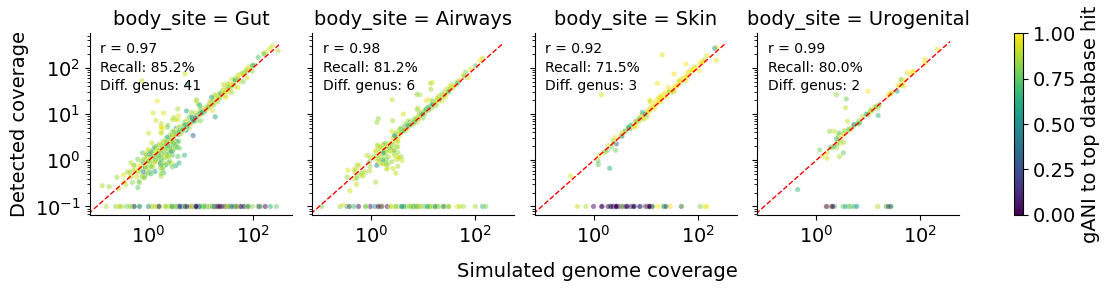

In [22]:
### Plot UHVDB sylph profile results
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob
plt.rcParams.update({'font.size': 14})

cov_lst = []
for file in glob.glob('virome_profiling/readsim/split_*_reads_cov.txt'):
    df = pl.read_csv(file, separator='\t').rename({'tname':'qname'})
    i = int(file.split('split_')[1].split('_')[0])

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"

    cov_lst.append(
        df
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )
cov_df = pl.concat(cov_lst)

df_lst = []

for i in range(1, 18):
    # each point represents an input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'virome_profiling/readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('virome_profiling/uhvdb_v4_blast/combined_renamed_v_uhvdb4.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani') # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load sylph data
    sylph_top_hit = (
        pl.read_csv(f'virome_profiling/uhvdb_v4_sylph_profile/split_{i}/split_{i}_uhvdb4_gtdb226.profile.tsv', separator='\t', ignore_errors=True) # load sylph data
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            .filter(pl.col('Adjusted_ANI') >= 95)
            .join(pl.read_csv('virome_profiling/uhvdb_v4_blast/combined_renamed_v_uhvdb4.anicalc.tsv', separator='\t'), left_on='contig_id', right_on='tname', how='left') # keep blast data for sylph hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only sylph v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of sylph (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each sylph genome
            .unique('contig_id', maintain_order=True) # keep only top input per sylph genome
            [['contig_id', 'qname', 'True_cov', 'Adjusted_ANI']]
    )

    # assign sylph coverages to input genome
    input_w_sylph = (
        input_genomes
            .join(sylph_top_hit, on='qname', how='left') # add sylph data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple sylph to an input, keep only sylph for top database hit
            .fill_null(0.1) # fill missing sylph hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"
    
    final_df = (
        input_w_sylph
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'Urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'Urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('True_cov') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('True_cov') > 0.1))['coverage'].to_list(), df.filter((pl.col('True_cov') > 0.1))['True_cov'].to_list()))

# plot breadth results
df = df.rename({'True_cov':'Detected coverage', 'coverage':'Simulated genome coverage'})
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Simulated genome coverage', 'Detected coverage', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="gANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# display r on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Simulated genome coverage'].to_list(),
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Detected coverage'].to_list()
    )[0]
    tp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Simulated genome coverage', ha='center', fontsize=14)

plt.show()

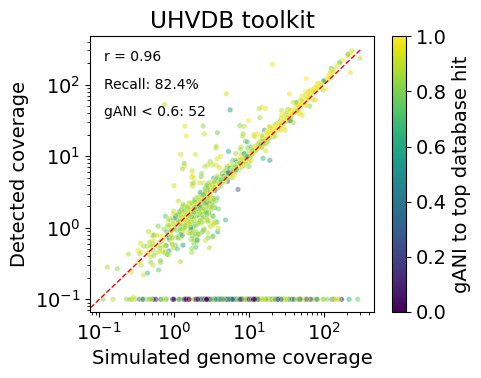

In [23]:
# plot breadth results (all body sites combined)
fig, ax = plt.subplots(figsize=(5, 4))

sns.scatterplot(
    data=df,
    x='Simulated genome coverage',
    y='Detected coverage',
    s=15,
    alpha=0.5,
    hue='qani',
    palette='viridis',
    hue_norm=(0, 1),
    ax=ax,
    legend=False
 )

# Add dynamic 1:1 line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Add colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="gANI to top database hit")

# Labels
ax.set_xlabel('Simulated genome coverage')
ax.set_ylabel('Detected coverage')

# Display summary stats on plot
r = pearsonr(
    df.filter(pl.col('Detected coverage') > 0.1)['Simulated genome coverage'].to_list(),
    df.filter(pl.col('Detected coverage') > 0.1)['Detected coverage'].to_list()
)[0]
tp = df.filter(pl.col('Detected coverage') > 0.1).unique('qname').height
fp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('qani') < 0.6)).unique('qname').height
total = df.unique('qname').height
recovery = tp / total * 100

ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.75, f'gANI < 0.6: {fp}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

ax.set_title('UHVDB toolkit')
plt.tight_layout()
plt.show()

Detected species > 0x- gut: 663 oral: 147 skin: 72 urogenital: 28
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 247
R-squared: PearsonRResult(statistic=np.float64(0.584698533073819), pvalue=np.float64(1.4713858374657934e-84))


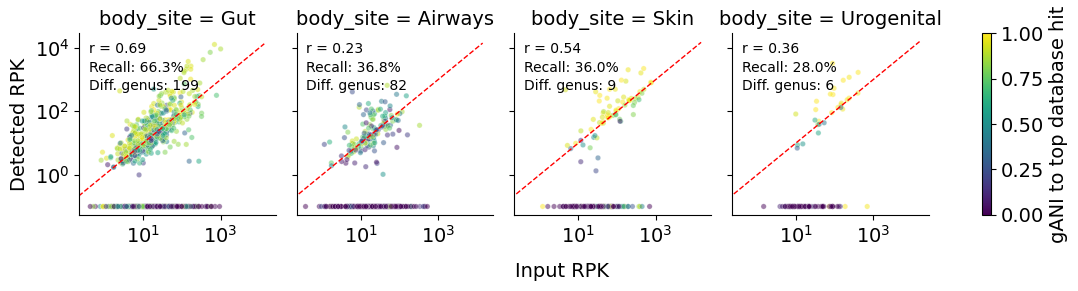

In [16]:
# baqlava
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

cov_lst = []
for file in glob.glob('virome_profiling/readsim/split_*_reads_cov.txt'):
    df = pl.read_csv(file, separator='\t').rename({'tname':'qname'})
    i = int(file.split('split_')[1].split('_')[0])

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"

    # convert coverage to rpk
    cov_lst.append(
        df
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
            .with_columns([
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
    )
cov_df = pl.concat(cov_lst)

df_lst = []


for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'virome_profiling/readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('virome_profiling/uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname),
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load baqlava data
    baqlava_top_hit = (
        pl.read_csv(f'virome_profiling/uhvdb_baqlava/split_{i}/split_{i}_reads_BAQLaVa_profile.txt', separator='\t', ignore_errors=True) # load baqlava data
            .filter(~pl.col('BAQLaVa VGB').str.contains('\\|'))
            .with_columns([
                pl.col(f'split_{i}_reads_Abundance-RPKs').alias('rpk'),
                pl.col('BAQLaVa VGB').alias('contig_id')
            ])
            .join(
                pl.read_csv('virome_profiling/baqlava_db/BAQLaVa_metadata_genomes.txt', separator='\t')[['Genome Name', 'VGB']],
                left_on='contig_id',
                right_on='VGB',
                how='left'
            )
            .join(pl.read_csv('virome_profiling/uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for baqlava hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only baqlava v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of baqlava (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each baqlava genome
            .unique('contig_id', maintain_order=True) # keep only top input per baqlava genome
            [['contig_id', 'qname', 'rpk']]
    )

    # assign baqlava coverages to input genome
    input_w_baqlava = (
        input_genomes
            .join(baqlava_top_hit, on='qname', how='left') # add baqlava data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple baqlava to an input, keep only baqlava for top database hit
            .fill_null(0.1) # fill missing baqlava hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"

    final_df = (
        input_w_baqlava
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'Urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'Urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('input_rpk') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpk') > 0.1))['input_rpk'].to_list(), df.filter((pl.col('rpk') > 0.1))['rpk'].to_list()))


# plot breadth results
df = df.rename({'rpk':'Detected RPK', 'input_rpk':'Input RPK'})
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPK', 'Detected RPK', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="gANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# display r on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Input RPK'].to_list(),
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Detected RPK'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')


# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPK', ha='center', fontsize=14)

plt.show()

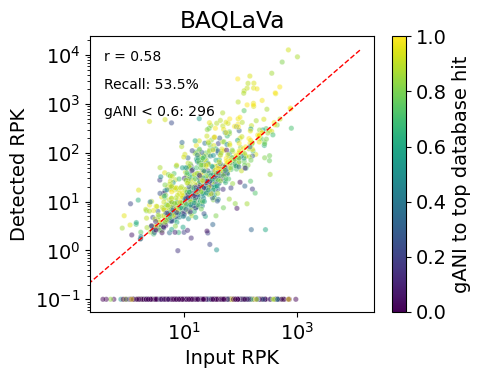

In [17]:
# baqlava (Figure 5B, all body sites combined)
fig, ax = plt.subplots(figsize=(5, 4))

sns.scatterplot(
    data=df,
    x='Input RPK',
    y='Detected RPK',
    s=15,
    alpha=0.5,
    hue='qani',
    palette='viridis',
    hue_norm=(0, 1),
    ax=ax,
    legend=False
)

# Add dynamic 1:1 line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Add colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="gANI to top database hit")

# Labels
ax.set_xlabel('Input RPK')
ax.set_ylabel('Detected RPK')

# Display summary stats on plot
r = pearsonr(
    df.filter(pl.col('Detected RPK') > 0.1)['Input RPK'].to_list(),
    df.filter(pl.col('Detected RPK') > 0.1)['Detected RPK'].to_list()
)[0]
tp = df.filter(pl.col('Detected RPK') > 0.1).unique('qname').height
fp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('qani') < 0.6)).unique('qname').height
total = df.unique('qname').height
recovery = tp / total * 100

ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.75, f'gANI < 0.6: {fp}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

ax.set_title('BAQLaVa')
plt.tight_layout()
plt.show()

Detected species > 0x- gut: 356 oral: 173 skin: 37 urogenital: 31
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 46
R-squared: PearsonRResult(statistic=np.float64(0.5659651409595926), pvalue=np.float64(7.437428503048128e-52))


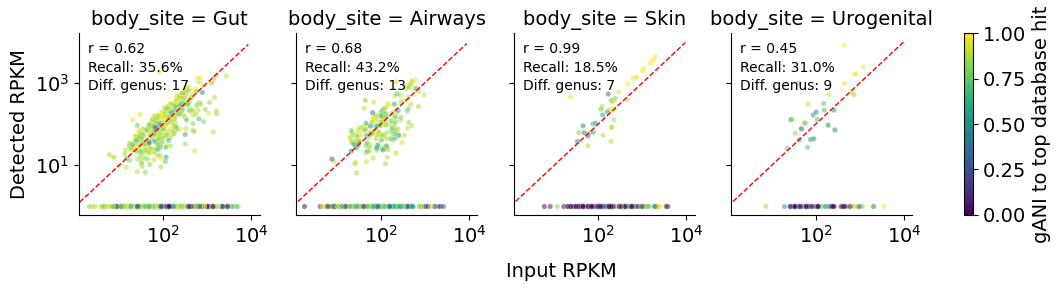

In [18]:
# marker-magu
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'virome_profiling/readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('virome_profiling/uhvdb_markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
                ((pl.col('coverage') * 1e9) / (600 * 100000)).alias('input_rpkm')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load magu data
    magu_top_hit = (
        pl.read_csv(f'virome_profiling/uhvdb_markermagu/split_{i}/split_{i}.detected_species.tsv', separator='\t', ignore_errors=True) # load magu data
            .with_columns([
                pl.col('RPKM').alias('rpkm'),
                pl.col('lineage').str.split('s__').list[1].alias('contig_id')
            ])
            .join(
                pl.read_csv('virome_profiling/marker_magu/v1.1/TGVG_v1.1_metadata.tsv', ignore_errors=True, separator='\t')
                    .with_columns([
                        pl.col('lineage').str.split('s_').list[1].alias('lineage')
                    ])
                    .rename({'contig_id': 'Genome Name'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('virome_profiling/uhvdb_markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for magu hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only magu v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of magu (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each magu genome
            .unique('contig_id', maintain_order=True) # keep only top input per magu genome
            [['contig_id', 'qname', 'rpkm']]
    )

    # assign magu coverages to input genome
    input_w_magu = (
        input_genomes
            .join(magu_top_hit, on='qname', how='full') # add magu data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple magu to an input, keep only magu for top database hit
            .fill_null(1) # fill missing magu hits with coverage of 1
    )

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"
    
    final_df = (
        input_w_magu
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpkm') > 1) & (pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpkm') > 1) & (pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpkm') > 1) & (pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpkm') > 1) & (pl.col('body_site') == 'Urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'Urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('rpkm') > 1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpkm') > 1))['coverage'].to_list(), df.filter((pl.col('rpkm') > 1))['rpkm'].to_list()))

# plot breadth results
df = df.rename({'rpkm':'Detected RPKM', 'input_rpkm':'Input RPKM'})
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPKM', 'Detected RPKM', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="gANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected RPKM') > 1) & (pl.col('body_site') == body_site))['Input RPKM'].to_list(),
        df.filter((pl.col('Detected RPKM') > 1) & (pl.col('body_site') == body_site))['Detected RPKM'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPKM') > 1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPKM') > 1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPKM', ha='center', fontsize=14)

plt.show()

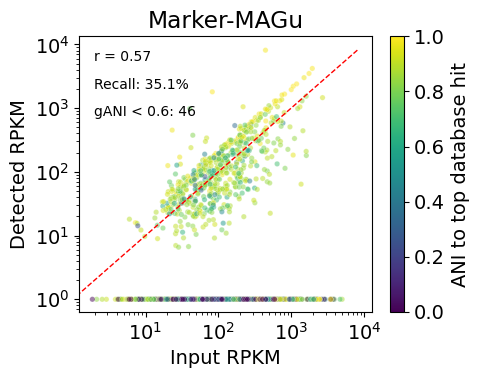

In [19]:
# marker-magu (Figure 5B, all body sites combined)
fig, ax = plt.subplots(figsize=(5, 4))

sns.scatterplot(
    data=df,
    x='Input RPKM',
    y='Detected RPKM',
    s=15,
    alpha=0.5,
    hue='qani',
    palette='viridis',
    hue_norm=(0, 1),
    ax=ax,
    legend=False
)

# Add dynamic 1:1 line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Add colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="ANI to top database hit")

# Labels
ax.set_xlabel('Input RPKM')
ax.set_ylabel('Detected RPKM')

# Display summary stats on plot
r = pearsonr(
    df.filter(pl.col('Detected RPKM') > 1)['Input RPKM'].to_list(),
    df.filter(pl.col('Detected RPKM') > 1)['Detected RPKM'].to_list()
)[0]
tp = df.filter(pl.col('Detected RPKM') > 1).unique('qname').height
fp = df.filter((pl.col('Detected RPKM') > 1) & (pl.col('qani') < 0.6)).unique('qname').height
total = df.unique('qname').height
recovery = tp / total * 100

ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.75, f'gANI < 0.6: {fp}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

ax.set_title('Marker-MAGu')
plt.tight_layout()
plt.show()

Detected species > 0x- gut: 311 oral: 116 skin: 39 urogenital: 22
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 35
R-squared: PearsonRResult(statistic=np.float64(0.48650592624331757), pvalue=np.float64(2.3178838700498287e-30))


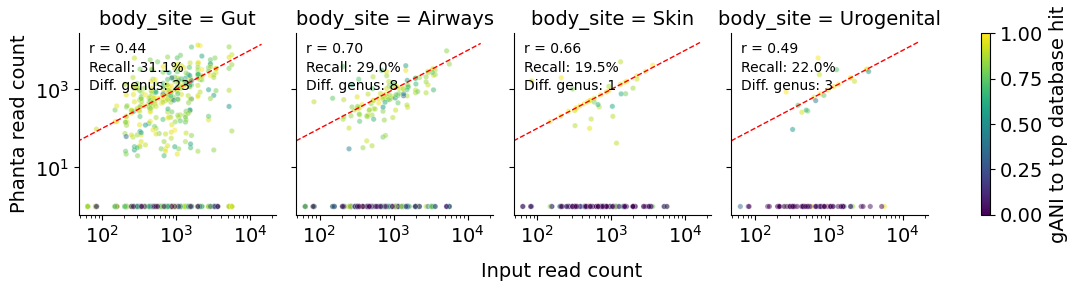

In [20]:
# phanta
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a phanta genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'virome_profiling/readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('virome_profiling/uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load phanta data
    phanta_top_hit = (
        pl.read_csv(f'virome_profiling/uhvdb_phanta/results/classification/split_{i}.krak.report.filtered.bracken.scaled', separator='\t', ignore_errors=True) # load phanta data
            .rename({'name':'contig_id'})
            .with_columns([
                (pl.col('new_est_reads')*2).alias('phanta_read_count'),
            ])
            .join(
                pl.read_csv('virome_profiling/uhvdb_phanta/votus_metadata.tsv', ignore_errors=True, separator='\t')
                    .rename({'uhgv_genome': 'Genome Name', 'uhgv_votu':'lineage'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('virome_profiling/uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for phanta hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only phanta v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of phanta (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each phanta genome
            .unique('contig_id', maintain_order=True) # keep only top input per phanta genome
            [['contig_id', 'qname', 'phanta_read_count']]
    )

    # assign phanta coverages to input genome
    input_w_phanta = (
        input_genomes
            .join(phanta_top_hit, on='qname', how='full') # add phanta data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple phanta to an input, keep only phanta for top database hit
            .fill_null(1) # fill missing phanta hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "Gut"
    elif i < 15:
        body_site = "Airways"
    elif i < 17:
        body_site = "Skin"
    else:
        body_site = "Urogenital"
    
    final_df = (
        input_w_phanta
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'Urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'Gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'Airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'Skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'Urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('phanta_read_count') > 1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('phanta_read_count') > 1))['read_count'].to_list(), df.filter((pl.col('phanta_read_count') > 1))['phanta_read_count'].to_list()))

# plot breadth results
df = df.rename({'phanta_read_count':'Phanta read count', 'read_count':'Input read count'})

g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input read count', 'Phanta read count', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="gANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Input read count'].to_list(),
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Phanta read count'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input read count', ha='center', fontsize=14)

plt.show()

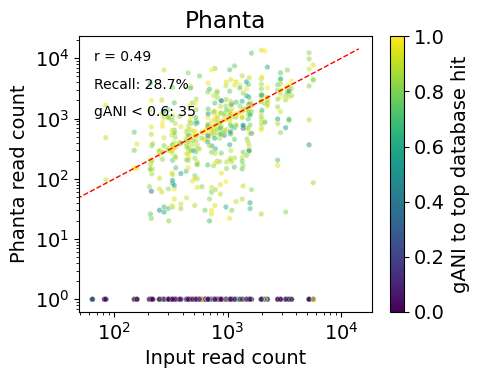

In [21]:
# phanta (Figure 5B, all body sites combined)
fig, ax = plt.subplots(figsize=(5, 4))

sns.scatterplot(
    data=df,
    x='Input read count',
    y='Phanta read count',
    s=15,
    alpha=0.5,
    hue='qani',
    palette='viridis',
    hue_norm=(0, 1),
    ax=ax,
    legend=False
)

# Add dynamic 1:1 line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Add colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="gANI to top database hit")

# Labels
ax.set_xlabel('Input read count')
ax.set_ylabel('Phanta read count')

# Display summary stats on plot
r = pearsonr(
    df.filter(pl.col('Phanta read count') > 1)['Input read count'].to_list(),
    df.filter(pl.col('Phanta read count') > 1)['Phanta read count'].to_list()
)[0]
tp = df.filter(pl.col('Phanta read count') > 1).unique('qname').height
fp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('qani') < 0.6)).unique('qname').height
total = df.unique('qname').height
recovery = tp / total * 100

ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')
ax.text(0.05, 0.75, f'gANI < 0.6: {fp}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

ax.set_title('Phanta')
plt.tight_layout()
plt.show()